# Effective Dimensionality

Measure the effective dimensionality of afferent and efferent hippocampal connectivity
profiles via spectral entropy (Del Giudice, 2021), treating each of the **72 target regions as
a sample in the 7-dimensional subfield space**.

Steps:

1. Build the **7×7 covariance matrix** of the 7 subfield-features (across the 72 samples).
2. Eigendecompose it to get the spectrum $\lambda_1, \dots, \lambda_7$.
3. Compute the spectral-entropy effective dimensionality $n_1$ (and $n_2$).

We run this **two ways** — on the **raw** profiles (magnitude + pattern) and on **L2
row-normalized** profiles (pattern/shape only) — and compare afferent vs efferent under each.

In [13]:
from helpers import get_feature_vectors_shared_hpc, log_weight_transform
import pandas as pd
import numpy as np

In [14]:
df_avg_to_shared, df_avg_from_shared = get_feature_vectors_shared_hpc()

df_avg_to_log = pd.DataFrame(
    log_weight_transform(df_avg_to_shared.values),
    index=df_avg_to_shared.index, 
    columns=df_avg_to_shared.columns,
)

df_avg_from_log = pd.DataFrame(
    log_weight_transform(df_avg_from_shared.values),
    index=df_avg_from_shared.index, 
    columns=df_avg_from_shared.columns,
)

## Spectral entropy → effective dimensionality (Del Giudice, 2021)

Each of the **72 target regions is a sample** in the **7-dimensional** hippocampal-subfield
feature space. So we take the **7×7 covariance matrix** of the 7 subfields (estimated across
the 72 samples) and read the effective dimensionality (ED) off its eigenvalue spectrum
$\lambda_1 \ge \dots \ge \lambda_7$.

**Normalize** the eigenvalues into a probability distribution $p_i = \lambda_i / \sum_j \lambda_j$.
Then (Del Giudice, 2021, Table 1):

- **Spectral (Shannon) entropy:** $H_1 = -\sum_i p_i \ln p_i$.
- **Effective dimensionality (Shannon):** $n_1 = e^{H_1} = \prod_i p_i^{-p_i}$ — his balanced,
  general-purpose estimator (the spectral-entropy one).
- **Participation ratio (quadratic entropy):** $n_2 = \dfrac{(\sum_i \lambda_i)^2}{\sum_i \lambda_i^2}$
  — a more conservative companion that downweights the small eigenvalues.

Both range from **1** (all variance in one direction → effectively 1-D) to **K = 7** (variance
spread equally across all 7 subfield dimensions).

**Two preprocessings.** We compute ED (a) on the **raw** log-weighted profiles — dimensionality
of connectivity *including magnitude* — and (b) after **L2-normalizing each sample (row)** to
unit length — dimensionality of connectivity *pattern/shape* only, with each region's overall
magnitude removed. Comparing the two isolates how much of each direction's dimensionality is
driven by magnitude vs by profile shape. (We use L2 rather than sum-to-1 normalization: sum-to-1
makes the data compositional — the features become linearly dependent, forcing one eigenvalue to
zero and inducing spurious negative correlations.)

In [15]:
# Del Giudice (2021) effective dimensionality from the 7x7 covariance spectrum.
# X: (n_samples, n_features) = 72 target regions x 7 subfields.
def effective_dimensionality(X):
    cov = np.cov(X, rowvar=False)                              # 7x7 covariance of the features
    eigenvalues = np.sort(np.clip(np.linalg.eigvalsh(cov), 0.0, None))[::-1]
    p = eigenvalues / eigenvalues.sum()                        # p_i = lambda_i / sum(lambda)
    nz = p > 0
    H1 = -np.sum(p[nz] * np.log(p[nz]))                        # spectral (Shannon) entropy
    n1 = np.exp(H1)                                            # Shannon ED = prod p_i^{-p_i}
    n2 = eigenvalues.sum() ** 2 / np.sum(eigenvalues ** 2)     # participation ratio (quadratic)
    return {'eigenvalues': eigenvalues, 'p': p, 'H1': H1, 'n1': n1, 'n2': n2}


def l2_normalize_rows(M):
    # Scale each sample (row) to unit L2 norm: keep the SHAPE of each region's 7-subfield
    # profile, discard its overall connection magnitude (the cosine-similarity philosophy).
    return M / np.linalg.norm(M, axis=1, keepdims=True)


# Feature matrices: rows = 72 target regions (samples), cols = 7 subfields (features).
# (.T on the 7x72 log blocks; the original DataFrames are left untouched, so this cell is
# safe to re-run.)
X_aff = df_avg_to_log.values.T       # afferent = partner -> HPC (TO the hippocampus)
X_eff = df_avg_from_log.values.T     # efferent = HPC -> partner (FROM the hippocampus)

# Two preprocessings:
#   raw -> dimensionality of connectivity INCLUDING magnitude
#   L2  -> dimensionality of connectivity PATTERN / shape only (magnitude removed)
ed = {
    ('afferent', 'raw'): effective_dimensionality(X_aff),
    ('afferent', 'L2'):  effective_dimensionality(l2_normalize_rows(X_aff)),
    ('efferent', 'raw'): effective_dimensionality(X_eff),
    ('efferent', 'L2'):  effective_dimensionality(l2_normalize_rows(X_eff)),
}

summary = pd.DataFrame(
    [{'direction': d, 'preprocessing': pp, 'H1 (nats)': v['H1'],
      'n1 [Shannon ED]': v['n1'], 'n2 [participation]': v['n2']}
     for (d, pp), v in ed.items()]
).set_index(['direction', 'preprocessing']).round(3)
print(summary.to_string())
print('\neffective dimensionality ranges from 1 to K = 7')

                         H1 (nats)  n1 [Shannon ED]  n2 [participation]
direction preprocessing                                                
afferent  raw                1.291            3.635               2.851
          L2                 1.640            5.157               4.385
efferent  raw                1.392            4.023               3.522
          L2                 1.067            2.906               2.434

effective dimensionality ranges from 1 to K = 7


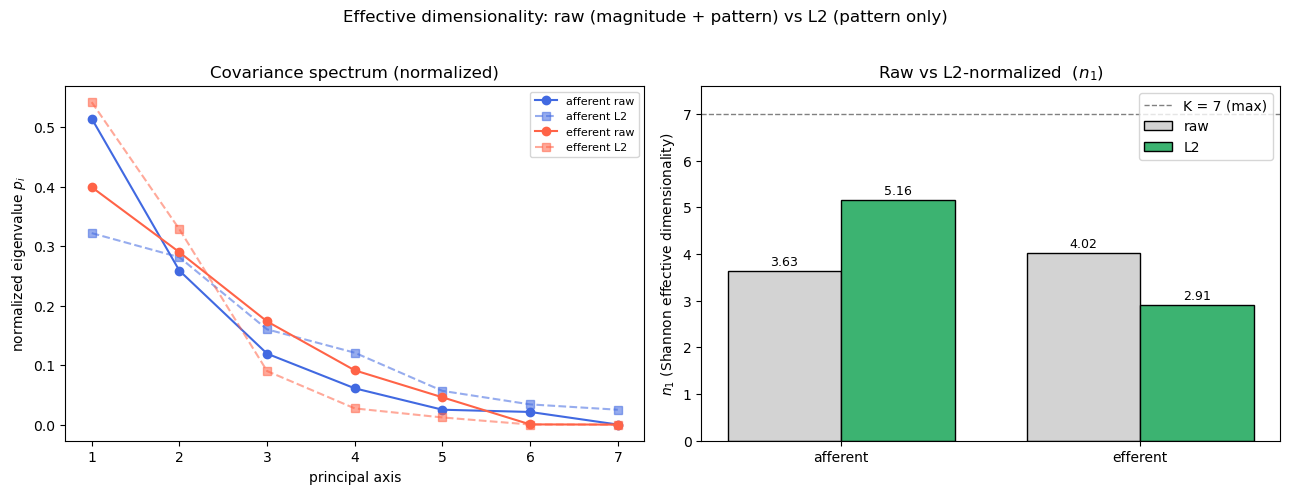

In [4]:
import matplotlib.pyplot as plt

K = 7
directions = ['afferent', 'efferent']
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# Left: normalized covariance spectra -- solid = raw, dashed = L2. Shows how L2 removes the
# dominant first ("overall magnitude") eigenvalue and rebalances the rest.
for d, color in [('afferent', 'royalblue'), ('efferent', 'tomato')]:
    axes[0].plot(range(1, K + 1), ed[(d, 'raw')]['p'], 'o-', color=color, label=f'{d} raw')
    axes[0].plot(range(1, K + 1), ed[(d, 'L2')]['p'], 's--', color=color, alpha=0.55,
                 label=f'{d} L2')
axes[0].set_xlabel('principal axis'); axes[0].set_ylabel(r'normalized eigenvalue $p_i$')
axes[0].set_title('Covariance spectrum (normalized)'); axes[0].set_xticks(range(1, K + 1))
axes[0].legend(fontsize=8)

# Right: n1 (Shannon ED), grouped by direction, raw vs L2 -- the ranking FLIPS.
xa, w = np.arange(len(directions)), 0.38
for off, pp, color in [(-w / 2, 'raw', 'lightgray'), (w / 2, 'L2', 'mediumseagreen')]:
    vals = [ed[(d, pp)]['n1'] for d in directions]
    bars = axes[1].bar(xa + off, vals, width=w, label=pp, color=color, edgecolor='k')
    axes[1].bar_label(bars, fmt='%.2f', padding=2, fontsize=9)
axes[1].axhline(K, color='gray', ls='--', lw=1, label=f'K = {K} (max)')
axes[1].set_xticks(xa); axes[1].set_xticklabels(directions)
axes[1].set_ylabel(r'$n_1$ (Shannon effective dimensionality)'); axes[1].set_ylim(0, K + 0.6)
axes[1].set_title('Raw vs L2-normalized  ($n_1$)'); axes[1].legend()

fig.suptitle('Effective dimensionality: raw (magnitude + pattern) vs L2 (pattern only)', y=1.02)
plt.tight_layout(); plt.show()

### Reading the comparison: magnitude vs pattern

The ranking **flips** with preprocessing, so the two analyses answer different questions:

- **Raw** (magnitude + pattern): **efferent** is higher-dimensional ($n_1 \approx 4.0$ vs $3.6$).
  Including connection strength, HPC's outgoing connectivity looks richer.
- **L2-normalized** (pattern/shape only): **afferent** is higher-dimensional
  ($n_1 \approx 5.2$ vs $2.9$) — the opposite.

Why the flip is informative: L2-normalization strips each region's overall magnitude and keeps
only the *shape* of its 7-subfield profile. Efferent ED **drops** when normalized (4.0 → 2.9),
so efferent variation across partners is mostly **magnitude** — HPC sends to partners at varying
strength but with a similar subfield-profile. Afferent ED **rises** (3.6 → 5.2): a dominant
overall-strength mode was masking genuinely **diverse input patterns** — partners project to HPC
with different subfield-preferences. In short: **HPC sends with a common profile at varying
strength; HPC receives genuinely different profiles.**

Two caveats to keep in mind:

- We use **L2** (unit-norm) row normalization, *not* sum-to-1. Sum-to-1 makes the data
  *compositional* (the 7 features become linearly dependent → one eigenvalue forced to 0, ED
  ceiling drops to 6, plus spurious negative correlations — Aitchison's closure problem).
- Efferent already has a dead dimension: **DG projects nowhere**, so its DG feature has zero
  variance and efferent's ED ceiling is 6, not 7, even before normalizing. Part of the
  afferent > efferent (pattern) gap reflects that ceiling difference, not only richer patterning.